Shape of left image: (819, 555)
Shape of right image: (811, 547)
Image dimensions do not match. Resizing images to common dimensions.
New shape of left image: (811, 547)
New shape of right image: (811, 547)


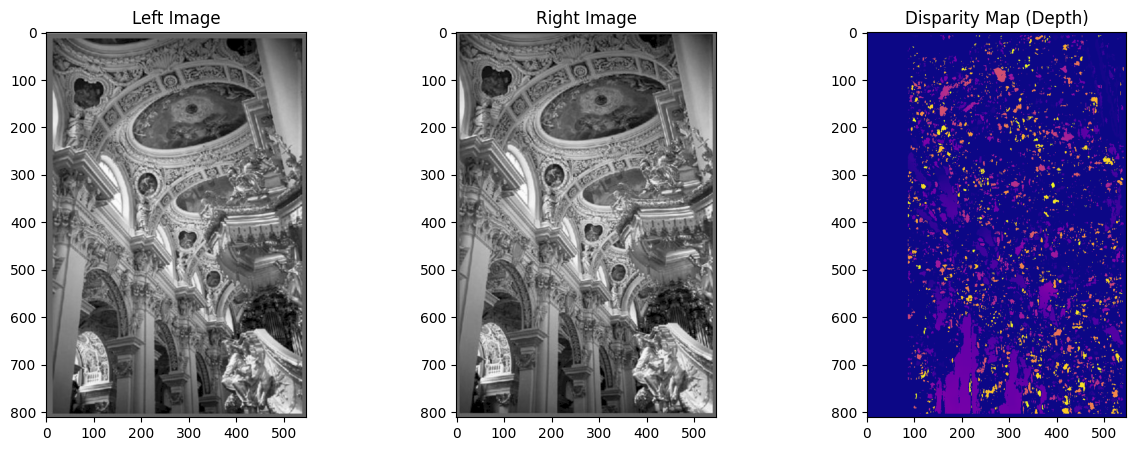

In [2]:
# Install OpenCV if needed
!pip install opencv-python matplotlib

# Import libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read stereo images (left and right images)
left_img  = cv2.imread('/content/Screenshot 2026-04-21 230950.png', 0)   # grayscale
right_img = cv2.imread('/content/Screenshot 2026-04-21 231010.png', 0)  # grayscale

# Check if images were loaded successfully
if left_img is None:
    print("Error: Left image not loaded. Please check the path: /content/Screenshot 2026-04-21 230950.png")
if right_img is None:
    print("Error: Right image not loaded. Please check the path: /content/Screenshot 2026-04-21 231010.png")

if left_img is not None and right_img is not None:
    print(f"Shape of left image: {left_img.shape}")
    print(f"Shape of right image: {right_img.shape}")

    # Resize images to have the same dimensions if they are different
    if left_img.shape != right_img.shape:
        print("Image dimensions do not match. Resizing images to common dimensions.")
        # Determine the common dimensions (e.g., minimum of both)
        min_height = min(left_img.shape[0], right_img.shape[0])
        min_width = min(left_img.shape[1], right_img.shape[1])

        left_img = cv2.resize(left_img, (min_width, min_height))
        right_img = cv2.resize(right_img, (min_width, min_height))
        print(f"New shape of left image: {left_img.shape}")
        print(f"New shape of right image: {right_img.shape}")

    # Create Stereo Block Matching object
    stereo = cv2.StereoBM_create(numDisparities=16*5, blockSize=15)

    # Compute disparity map
    disparity = stereo.compute(left_img, right_img)

    # Normalize disparity for visualization
    disparity_norm = cv2.normalize(disparity, None, alpha=0, beta=255,
                                  norm_type=cv2.NORM_MINMAX)

    # Display images
    plt.figure(figsize=(15,5))

    plt.subplot(1,3,1)
    plt.title("Left Image")
    plt.imshow(left_img, cmap='gray')

    plt.subplot(1,3,2)
    plt.title("Right Image")
    plt.imshow(right_img, cmap='gray')

    plt.subplot(1,3,3)
    plt.title("Disparity Map (Depth)")
    plt.imshow(disparity_norm, cmap='plasma')

    plt.show()